## H1N1 Vaccine Uptake Prediction Project
### 1. Project Overview

Vaccination is one of the most effective strategies for preventing infectious diseases and reducing their spread. During the 2009 pandemic of H1N1 influenza, governments and health organizations encouraged mass vaccination to protect populations from infection and severe illness. However, vaccine uptake varied significantly across different groups of people due to differences in demographics, health behaviors, and perceptions about vaccine safety and effectiveness.

This project aims to predict whether an individual received the H1N1 vaccine using data from the National 2009 H1N1 Flu Survey. The dataset contains information on respondents’ demographic characteristics, health conditions, preventive behaviors, and opinions about vaccines and disease risk.

Using machine learning classification models, the project analyzes these factors to identify patterns associated with vaccine acceptance. Understanding these patterns can help public health organizations design more effective vaccination campaigns, improve risk communication, and increase vaccine coverage during future disease outbreaks such as COVID-19.

The final model predicts the likelihood that a person receives the H1N1 vaccine and highlights the key predictors influencing vaccination behavior. These insights can support evidence-based decision making for public health interventions and vaccination strategies.

### 2. Problem Statement

During pandemic outbreaks, vaccination programs are critical in reducing infection rates and protecting vulnerable populations. However, not everyone chooses to receive vaccines, even when they are widely available. Public health authorities often struggle to understand which factors influence vaccine acceptance and which populations are less likely to get vaccinated. Without this knowledge, vaccination campaigns may fail to effectively reach high-risk or vulnerable groups.

This project addresses this challenge by developing a predictive model that determines whether an individual received the H1N1 vaccine based on demographic characteristics, health behaviors, and attitudes toward vaccination.

The goal is to identify patterns that explain vaccination behavior and provide insights that can inform future vaccination strategies.

### 3. Project Objectives
##### General Objective
To build a machine learning model that predicts whether individuals received the H1N1 vaccine using demographic, behavioral, and attitudinal data.

##### Specific Objectives
- To explore the National 2009 H1N1 Flu Survey dataset and understand its key variables.
- To perform data cleaning and preprocessing, including handling missing values and encoding categorical variables.
- To conduct exploratory data analysis (EDA) to identify patterns and relationships between features and vaccination status.
- To build classification models that predict whether an individual received the H1N1 vaccine.
- To evaluate model performance using appropriate classification metrics.
- To identify the most important factors influencing H1N1 vaccine uptake.
- To generate insights that can support future public health vaccination strategies.

### 4. Stakeholders
1. Public Health Organizations
Organizations such as the WHO, CDC rely on vaccination data to understand which populations are more or less likely to receive vaccines. Insights from the analysis can help them design targeted vaccination campaigns and improve public health strategies.
2. Healthcare Providers
Doctors, nurses, and healthcare institutions play a direct role in recommending vaccines to patients. Understanding factors influencing vaccine uptake can help them better communicate the importance of vaccination.
3. Government Health Policy Makers
Policy makers use vaccination behavior data to create policies that improve vaccine accessibility and coverage, especially during outbreaks or pandemics.
4. Public Health Researchers and Epidemiologists
Researchers studying infectious diseases can use the results to understand behavioral and demographic factors influencing vaccination decisions.

### 5. Data Understanding
The dataset used in this project comes from the National 2009 H1N1 Flu Survey, which was conducted to understand public attitudes and behaviors regarding vaccination during the H1N1 pandemic.
The dataset includes variables that describe:
Demographic Characteristics
-Age group
- Education level
- Household income
- Employment status
- Geographic region
Health Status
- Presence of chronic medical conditions
- Health insurance coverage
- Healthcare access
Preventive Behaviors
- Frequency of hand washing
- Use of face masks
- Health precautions

Attitudes and Perceptions
- Perceived risk of H1N1 infection
- Perceived effectiveness of the vaccine
- Concerns about vaccine safety
- Trust in healthcare recommendations

The target variable for this project is:
- 1 = Respondent received the H1N1 vaccine
- 0 = Respondent did not receive the H1N1 vaccine

## Data preparation and cleaning
Import all libraries needed

In [184]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeCV, LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import VotingRegressor, StackingRegressor, BaggingRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

##### Loading datasets and having an overview of the first 5 rows

In [185]:
# Read in features
df_features = pd.read_csv('data/training_set_features.csv')
df_features.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb


In [186]:
# Read in targets
df_targets = pd.read_csv('data/training_set_labels.csv')
df_targets.head()

,respondent_id,h1n1_vaccine,seasonal_vaccine
0,0,0,0
1,1,0,1
2,2,0,0
3,3,0,1
4,4,0,0


In [187]:
df_test =pd.read_csv('data/test_set_features.csv')
df_test.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
0,26707,2.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,"> $75,000",Not Married,Rent,Employed,mlyzmhmf,"MSA, Not Principle City",1.0,0.0,atmlpfrs,hfxkjkmi
1,26708,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Below Poverty,Not Married,Rent,Employed,bhuqouqj,Non-MSA,3.0,0.0,atmlpfrs,xqwwgdyp
2,26709,2.0,2.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,...,"> $75,000",Married,Own,Employed,lrircsnp,Non-MSA,1.0,0.0,nduyfdeo,pvmttkik
3,26710,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,"<= $75,000, Above Poverty",Married,Own,Not in Labor Force,lrircsnp,"MSA, Not Principle City",1.0,0.0,NaN,NaN
4,26711,3.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,...,"<= $75,000, Above Poverty",Not Married,Own,Employed,lzgpxyit,Non-MSA,0.0,1.0,fcxhlnwr,mxkfnird


In [188]:
# Join on respondent_id and isolate H1N1
df = df_features.join(df_targets[['h1n1_vaccine']])
df.head() #display the first 5 rows

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0


In [189]:
#drop columns related to seasonal vaccine
df= df.drop(columns=['opinion_seas_risk','opinion_seas_vacc_effective','opinion_seas_sick_from_vacc', 'doctor_recc_seasonal'])

In [190]:
df.shape #number of columns and rows for the dataset

(26707, 33)

In [191]:
df.info() # checking dataset info

<class 'pandas.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  chronic_med_condition        25736 non-null  float64
 12  child_under_6_months         25887 non-null  float64
 13  health_worker              

In [192]:
df.describe()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,household_adults,household_children,h1n1_vaccine
count,26707.000000,26615.000000,26591.000000,26636.000000,26499.000000,26688.000000,26665.000000,26620.00000,26625.000000,26579.000000,...,25736.000000,25887.000000,25903.000000,14433.00000,26316.000000,26319.000000,26312.000000,26458.000000,26458.000000,26707.000000
mean,13353.000000,1.618486,1.262532,0.048844,0.725612,0.068982,0.825614,0.35864,0.337315,0.677264,...,0.283261,0.082590,0.111918,0.87972,3.850623,2.342566,2.357670,0.886499,0.534583,0.212454
std,7709.791156,0.910311,0.618149,0.215545,0.446214,0.253429,0.379448,0.47961,0.472802,0.467531,...,0.450591,0.275266,0.315271,0.32530,1.007436,1.285539,1.362766,0.753422,0.928173,0.409052
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,6676.500000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.00000,3.000000,1.000000,1.000000,0.000000,0.000000,0.000000
50%,13353.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.00000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.00000,4.000000,2.000000,2.000000,1.000000,0.000000,0.000000
75%,20029.500000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,...,1.000000,0.000000,0.000000,1.00000,5.000000,4.000000,4.000000,1.000000,1.000000,0.000000
max,26706.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.00000,5.000000,5.000000,5.000000,3.000000,3.000000,1.000000


### Exploratory data visualizations

In [193]:
df2 = df.copy()

- To see the overall balance of the target variable. Helps us know if the dataset is skewed toward vaccinated or non-vaccinated individuals

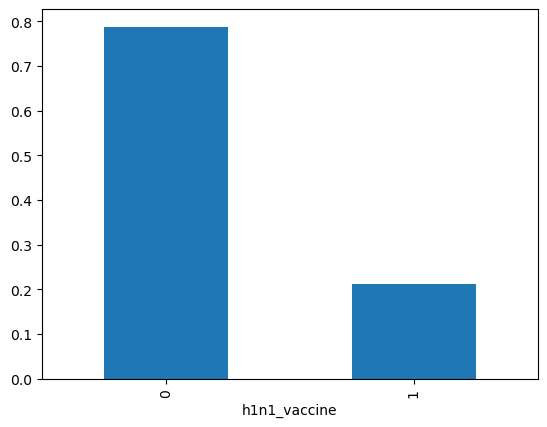

In [194]:
# Target variable distribution
df['h1n1_vaccine'].value_counts(normalize=True).plot(kind='bar');

- To explore if gender influences vaccination uptake

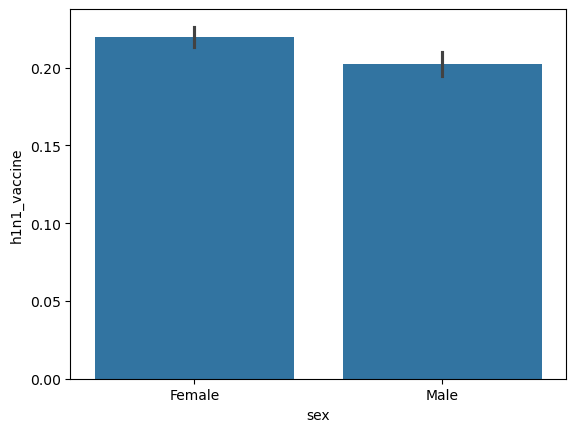

In [195]:
# Gender and h1n1 vaccination status bar graph
sns.barplot(x=df['sex'], y=df['h1n1_vaccine']);

- Education level percentage distribution of vaccinated people

<Axes: xlabel='education', ylabel='h1n1_vaccine'>

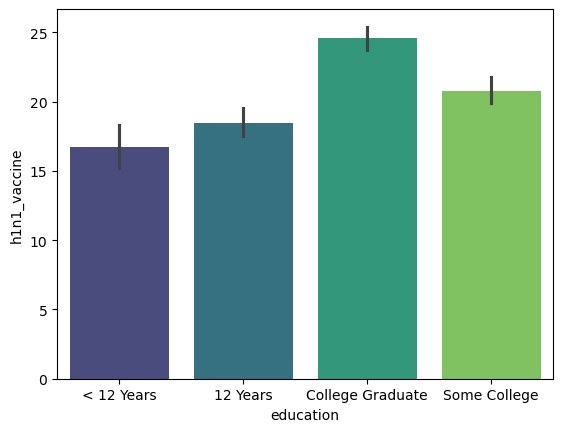

In [196]:
# Education level percentage distribution of the vaccinated people 
sns.barplot(x=df['education'], y=df['h1n1_vaccine']*100, palette='viridis')

- Health workers are expected to be more informed; we want to verify if they are more likely to vaccinate

Text(0.5, 0, 'Health Worker Status')

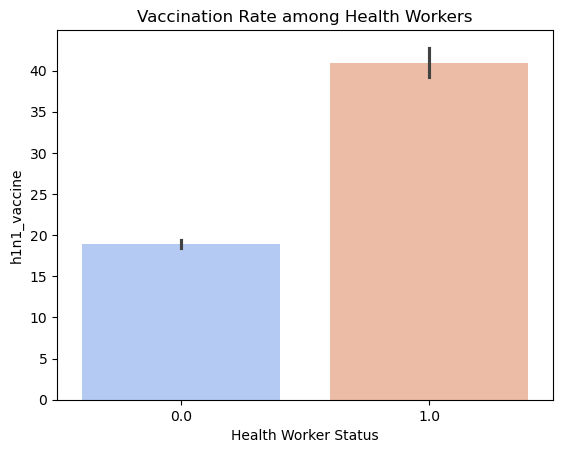

In [197]:
# Distribution of health workers who got the vaccine
sns.barplot(x=df['health_worker'], y=df['h1n1_vaccine']*100, palette='coolwarm')
plt.title('Vaccination Rate among Health Workers')
plt.xlabel('Health Worker Status')

- To see the effect of a doctor’s recommendation on vaccination decisions.
- Usually shows that people whose doctors recommended the vaccine are far more likely to get vaccinated, one of the strongest predictors in the dataset

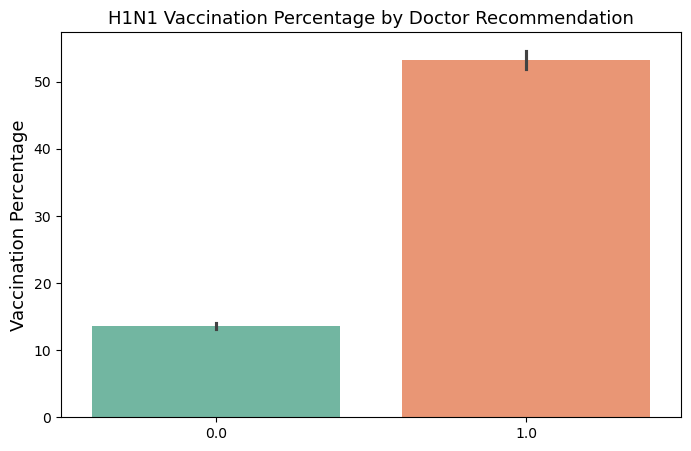

In [198]:
# Graph for relationship between H1N1 vaccination and Doctor recommendation
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=df2['doctor_recc_h1n1'].dropna(), y=df2['h1n1_vaccine']*100, palette='Set2')
ax.set_xlabel('')
ax.set_ylabel('Vaccination Percentage', fontsize=13)
ax.set_title('H1N1 Vaccination Percentage by Doctor Recommendation', fontsize=13)
plt.show()

- To explore if knowledge about H1N1 affects vaccination uptake.

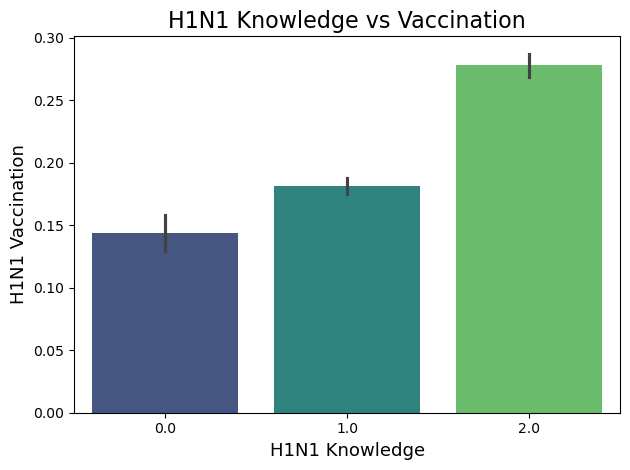

In [199]:
# Creating the bar plot with X = h1n1_knowledge and Y = h1n1_vaccine
sns.barplot(data = df, x=df['h1n1_knowledge'], y=df['h1n1_vaccine'], palette='viridis')
# Setting title and labels
plt.title('H1N1 Knowledge vs Vaccination', fontsize=16)
plt.xlabel('H1N1 Knowledge', fontsize=13)
plt.ylabel('H1N1 Vaccination', fontsize=13)
plt.tight_layout()

### Key results
Target distribution: Most individuals did not receive the H1N1 vaccine, indicating a slight class imbalance.

Gender: Minor differences in vaccination rates; gender is not a strong predictor.

Education: Higher education levels correspond to higher vaccination rates, suggesting awareness influences uptake.

Health workers: More likely to get vaccinated compared to non-health workers, showing occupation and exposure matter.

Doctor recommendation: The strongest predictor; individuals advised by their doctor are substantially more likely to vaccinate.

H1N1 knowledge: Greater knowledge correlates with higher vaccination likelihood, highlighting the role of awareness.

- Correlation analysis

In [200]:
# Select numeric columns only
numeric_df = df.select_dtypes(include=['number'])

# Compute correlations with the target
corr_with_target = numeric_df.corr()['h1n1_vaccine'].sort_values(ascending=False)

# Print top 5
print("Top 10 features correlated with h1n1_vaccine:\n")
print(corr_with_target.head(10))

Top 10 features correlated with h1n1_vaccine:

h1n1_vaccine                   1.000000
doctor_recc_h1n1               0.393890
opinion_h1n1_risk              0.323265
opinion_h1n1_vacc_effective    0.269347
health_worker                  0.169768
h1n1_concern                   0.121929
health_insurance               0.121170
h1n1_knowledge                 0.117951
chronic_med_condition          0.095207
opinion_h1n1_sick_from_vacc    0.075091
Name: h1n1_vaccine, dtype: float64


### Check Missing Values

In [201]:
df.isnull().sum().sort_values(ascending=False)

employment_occupation          13470
employment_industry            13330
health_insurance               12274
income_poverty                  4423
doctor_recc_h1n1                2160
rent_or_own                     2042
employment_status               1463
marital_status                  1408
education                       1407
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
opinion_h1n1_sick_from_vacc      395
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
household_adults                 249
household_children               249
behavioral_avoidance             208
behavioral_touch_face            128
h1n1_knowledge                   116
h1n1_concern                      92
behavioral_large_gatherings       87
behavioral_outside_home           82
behavioral_antiviral_meds         71
behavioral_wash_hands             42
behavioral_face_mask              19
respondent_id                      0
a

### Split Data into Train and Test Sets
The dataset was split into training and testing sets before handling missing values to prevent data leakage. 
Missing value imputation statistics were calculated using only the training data and then applied to the test data to ensure that the model evaluation reflects real-world performance.

In [202]:
# Split the data into training and testing subsets (80-20 split)
# Features (everything except our target and ID)
X = df.drop(columns=['h1n1_vaccine', 'respondent_id'])

# Target
y = df['h1n1_vaccine']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=42,    # Ensures reproducibility
    stratify=y          # Maintains the 21% vaccine ratio in both sets
)

print(f"Training set size: {X_train.shape} rows")
print(f"Testing set size: {X_test.shape} rows")

Training set size: (21365, 31) rows
Testing set size: (5342, 31) rows


## Data cleaning
### Handling Missing values
- Most variables are either Binary (0/1) or Ordinal (scale of 0–3). The safest approach for such health model is to use the Median for numerical/ordinal columns and the Mode for categorical columns.
- Missing values in numerical features were imputed using the median, while categorical features were imputed using the most frequent value, fitted on the training data to avoid data leakage
- Machine learning models cannot work directly with categorical variables such as education, marital_status, or race. These variables must be converted into numerical form. One-Hot Encoding is used to transform categorical variables into binary columns.

In [203]:
# Identify numeric and categorical columns
num_cols = X_train.select_dtypes(include=['number']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

# Preprocessing for numeric columns: impute missing values with median
num_transformer = SimpleImputer(strategy='median')

# Preprocessing for categorical columns: impute missing values + one-hot encode
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing for numeric and categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

# Fit the preprocessor on training data and transform both train and test sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get the new feature names (for categorical columns)
encoded_cat_cols = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_cols)
all_cols = list(num_cols) + list(encoded_cat_cols)

# Convert back to DataFrame
X_train = pd.DataFrame(X_train_processed, columns=all_cols, index=X_train.index)
X_test = pd.DataFrame(X_test_processed, columns=all_cols, index=X_test.index)

print(f"Missing values remaining: {X_train.isnull().sum().sum()}")
print(f"Missing values remaining: {X_test.isnull().sum().sum()}")

Missing values remaining: 0
Missing values remaining: 0
